# Building the main table

The first notebook checked the raw files and found the problems in them. This one puts
the pieces together into the single table everything else will be built on.

**One row = one map played.** Each row says: when it was played, which two teams played it,
the five agents each team used, who chose that map, and who won.

We work map by map rather than match by match for two reasons:

- There are 1,272 maps but only about 500 matches, so this gives us more than twice as
  much to learn from.
- Teams choose their agents fresh for every map. So the map is the level where the
  question "does this combination of agents win?" is actually being asked.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

from dataset import build_map_table

## 1. Build it

`src/dataset.py` does the assembly. It applies the four fixes found in notebook 01 —
each one is needed for the numbers to come out right, not just for tidiness:

1. **Drop the summary rows.** The player file mixes whole-match summary rows in with the
   real per-map rows. Leaving them in would count many maps twice.
2. **Keep one row per player per map.** That file lists every player three times — once
   for the whole map, once for the attacking half, once for the defending half.
3. **Fix NRG's name.** NRG is stored as "Mega Minors" in the team columns but as "NRG"
   everywhere else, so matching teams by name would lose all 25 of their matches.
4. **Remove exhibition matches.** Five all-star/showmatch games use made-up teams that
   never play again, so they teach us nothing.

In [2]:
maps = build_map_table()

print(f"{len(maps):,} maps, {len(maps.columns)} columns")
maps.head()

1,272 maps, 17 columns


,match_id,game_id,played_at,event,tournament,stage,match_type,match_name,map,team_a,team_b,comp_a,comp_b,map_picked_by,score_a,score_b,team_a_won
0,430838,196667,2025-01-11 14:30:00,VCT 2025 China Kickoff,VCT 2025: China Kickoff,Main Event,Upper Round 1,TYLOO vs Titan Esports Club,Fracture,TYLOO,Titan Esports Club,"(breach, brimstone, killjoy, raze, sova)","(breach, brimstone, fade, killjoy, raze)",team_b,11,13,0
1,430838,196668,2025-01-11 14:30:00,VCT 2025 China Kickoff,VCT 2025: China Kickoff,Main Event,Upper Round 1,TYLOO vs Titan Esports Club,Abyss,TYLOO,Titan Esports Club,"(astra, jett, omen, sova, yoru)","(cypher, jett, kayo, omen, sova)",team_a,10,13,0
2,430837,196664,2025-01-11 17:05:00,VCT 2025 China Kickoff,VCT 2025: China Kickoff,Main Event,Upper Round 1,Xi Lai Gaming vs Wolves Esports,Lotus,Xi Lai Gaming,Wolves Esports,"(breach, cypher, neon, omen, sova)","(breach, fade, omen, raze, vyse)",team_a,13,11,1
3,430837,196665,2025-01-11 17:05:00,VCT 2025 China Kickoff,VCT 2025: China Kickoff,Main Event,Upper Round 1,Xi Lai Gaming vs Wolves Esports,Split,Xi Lai Gaming,Wolves Esports,"(cypher, omen, raze, skye, viper)","(cypher, omen, raze, skye, vyse)",team_b,13,9,1
4,430839,196670,2025-01-12 14:30:00,VCT 2025 China Kickoff,VCT 2025: China Kickoff,Main Event,Upper Round 1,JDG Esports vs Dragon Ranger Gaming,Abyss,JDG Esports,Dragon Ranger Gaming,"(astra, jett, omen, sova, yoru)","(astra, jett, kayo, omen, sova)",team_a,5,13,0


### What each column means

| Column | What it is |
|---|---|
| `match_id`, `game_id` | Reference numbers for the match and for this specific map |
| `played_at` | When the match was played |
| `event`, `tournament`, `stage`, `match_type` | Which competition this was part of |
| `map` | Which of the 11 maps was played |
| `team_a`, `team_b` | The two teams. A and B is just listing order and means nothing else |
| `comp_a`, `comp_b` | The five agents each team played, in alphabetical order |
| `map_picked_by` | Whether team A chose this map, team B chose it, or it was the decider |
| `score_a`, `score_b` | Rounds won by each team |
| `team_a_won` | 1 if team A won the map, 0 if team B did. **This is what we are trying to predict** |

On `map_picked_by`: before a match, teams take turns removing and choosing maps. If the
match goes all the way to a final map, that last one is whatever nobody removed — the
"decider". Nobody picked it, so it gets its own label rather than being treated as missing.

## 2. Checking nothing went wrong

Combining files is where mistakes hide. If a team's name is spelled differently in two
files, rows quietly vanish and everything afterwards is wrong without any error appearing.
So we check rather than assume.

In [3]:
from dataset import MATCH_KEY, load_primary

raw_maps = load_primary("matches/maps_scores.csv")
raw_scores = load_primary("matches/scores.csv")
n_exhibition_maps = raw_maps.merge(
    raw_scores[raw_scores["Stage"] == "Showmatch"][MATCH_KEY].drop_duplicates(), on=MATCH_KEY
).shape[0]

print(f"maps in the raw file         : {len(raw_maps):,}")
print(f"exhibition maps removed      : {n_exhibition_maps}")
print(f"expected to be left          : {len(raw_maps) - n_exhibition_maps:,}")
print(f"actually in our table        : {len(maps):,}")
print()
print(f"any empty values?            : {maps.isna().sum().sum()}")
print(f"every map appears once?      : {maps['game_id'].is_unique}")
print(f"rows sorted oldest first?    : {maps['played_at'].is_monotonic_increasing}")
print(f"every team has 5 agents?     : {maps['comp_a'].map(len).eq(5).all() and maps['comp_b'].map(len).eq(5).all()}")
print(f"any map ending in a draw?    : {(maps['score_a'] == maps['score_b']).any()}")

maps in the raw file         : 1,277
exhibition maps removed      : 5
expected to be left          : 1,272
actually in our table        : 1,272

any empty values?            : 0
every map appears once?      : True
rows sorted oldest first?    : True
every team has 5 agents?     : True
any map ending in a draw?    : False


In [4]:
# A team should never appear as its own opponent, and the winner should always
# be whoever scored more rounds. Both obvious -- which is why they are worth checking.
print(f"a team playing itself?       : {(maps['team_a'] == maps['team_b']).any()}")
print(f"winner always outscored loser: {(maps['team_a_won'] == (maps['score_a'] > maps['score_b'])).all()}")
print()
print(f"teams: {pd.concat([maps['team_a'], maps['team_b']]).nunique()}")
print(f"maps : {maps['map'].nunique()}")
print(f"agents used: {pd.Series([a for c in maps['comp_a'] for a in c]).nunique()}")
print(f"season: {maps['played_at'].min().date()} to {maps['played_at'].max().date()}")

a team playing itself?       : False
winner always outscored loser: True

teams: 48
maps : 11
agents used: 27
season: 2025-01-11 to 2025-10-05


## 3. Is the thing we're predicting balanced?

Team A wins about half the time, which is what we want. A and B is only the order the
teams happen to be listed in, so if one side won far more often it would mean something
odd was going on in how the data was recorded.

In [5]:
print(f"team A won {maps['team_a_won'].mean():.1%} of maps")
print()
print("Because it is this even, a model that blindly guesses 'team A' every time")
print("would be right about half the time. That is the bar anything we build must beat.")

team A won 51.1% of maps

Because it is this even, a model that blindly guesses 'team A' every time
would be right about half the time. That is the bar anything we build must beat.


## 4. A first real question: does choosing the map help you win it?

Teams pick maps they think they are good at, so we would expect picking to help. If it
does, then who picked the map is worth including as something the model can use — and it
is known before anyone plays a round, which is exactly what we need.

In [6]:
picked_by_a = maps[maps["map_picked_by"] == "team_a"]
picked_by_b = maps[maps["map_picked_by"] == "team_b"]

picker_wins = int(picked_by_a["team_a_won"].sum() + (1 - picked_by_b["team_a_won"]).sum())
picked_total = len(picked_by_a) + len(picked_by_b)

print(f"maps chosen by one of the teams : {picked_total:,}")
print(f"won by the team that chose it   : {picker_wins:,}  ({picker_wins / picked_total:.1%})")
print()
print(f"decider maps (nobody chose)     : {(maps['map_picked_by'] == 'decider').sum()}")

maps chosen by one of the teams : 1,047
won by the team that chose it   : 563  (53.8%)

decider maps (nobody chose)     : 225


So choosing the map is worth roughly **four extra wins in every hundred maps**. A real
advantage, but a small one — nowhere near enough to predict matches on its own. That is
useful to know now: it tells us the map choice is worth including, but that most of what
decides a map must lie elsewhere.

## 5. The game changes over the season

This matters more than anything else in this notebook, so it is worth being clear about why.

Valorant gets updated through the year. Agents are made stronger or weaker, and teams
change what they play in response. So the agents that win in January are not the agents
that win in September.

Here is that happening — how often each agent was played in the first third of the season
compared with the last third.

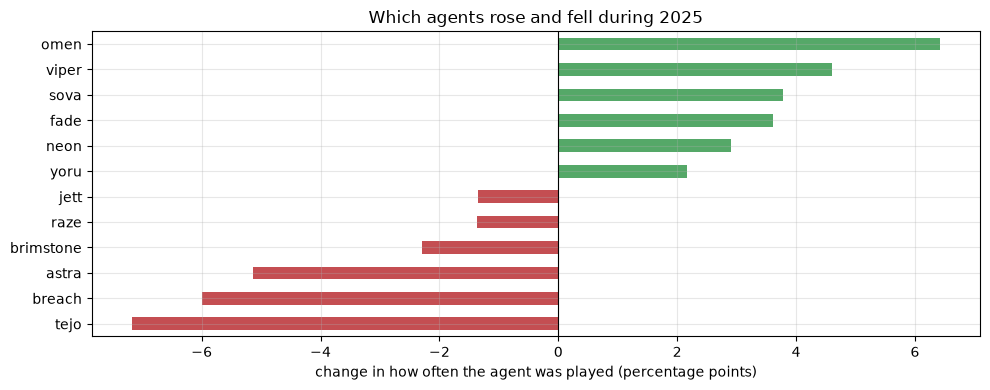

,early season,late season,change
tejo,8.0,0.8,-7.2
breach,7.8,1.8,-6.0
astra,6.3,1.2,-5.1
brimstone,4.1,1.8,-2.3
raze,6.6,5.3,-1.4
jett,4.6,3.3,-1.3
yoru,5.9,8.0,2.2
neon,3.3,6.2,2.9
fade,4.7,8.3,3.6
sova,6.7,10.5,3.8


In [7]:
def agent_usage(rows: pd.DataFrame) -> pd.Series:
    """How often each agent was played, as a share of all agent picks."""
    played = [agent for comp in list(rows["comp_a"]) + list(rows["comp_b"]) for agent in comp]
    return pd.Series(played).value_counts(normalize=True) * 100


third = len(maps) // 3
usage = pd.DataFrame(
    {"early season": agent_usage(maps.head(third)), "late season": agent_usage(maps.tail(third))}
).fillna(0)
usage["change"] = usage["late season"] - usage["early season"]

biggest = pd.concat([usage.nlargest(6, "change"), usage.nsmallest(6, "change")]).sort_values("change")

ax = biggest["change"].plot.barh(
    color=["#c44e52" if v < 0 else "#55a868" for v in biggest["change"]]
)
ax.set_xlabel("change in how often the agent was played (percentage points)")
ax.set_title("Which agents rose and fell during 2025")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

biggest.round(1)

These are big changes. Tejo went from one of the most played agents to almost never
played. Breach and Astra nearly disappeared too, while Omen went from being in about one
in ten line-ups to one in six.

**Why this decides how we test the model.** If we shuffled all the maps and randomly split
them into a "learn from" pile and a "test on" pile, the model would be learning from
September matches and being tested on March ones. It would already know how the season
turned out. Its score would look great and would mean nothing, because a real prediction
never gets to see the future.

So we split by **time** instead: learn from the earlier part of the season, test on the
later part. That is the same position a real prediction would be in.

This is very likely why one of the similar projects we looked at reported 93% accuracy —
a number far too high to be believable for esports.

## 6. Where to split the season

We split after Masters Toronto, in late June. Everything before it is used for learning,
everything after it for testing.

The split lands in the gap between two tournaments, so no single tournament is cut in half
across both sides. That matters because teams within one tournament play each other
repeatedly — splitting mid-tournament would let the model learn how a specific run of
games was going and then be tested on the rest of it.

In [8]:
SPLIT_DATE = pd.Timestamp("2025-06-23")

learn_from = maps[maps["played_at"] < SPLIT_DATE]
test_on = maps[maps["played_at"] >= SPLIT_DATE]

print(f"learn from : {len(learn_from):,} maps  ({len(learn_from) / len(maps):.0%})")
print(f"test on    : {len(test_on):,} maps  ({len(test_on) / len(maps):.0%})")
print()
print("learn from these events:")
for e in sorted(learn_from["event"].unique()):
    print(f"   {e}")
print("\ntest on these events:")
for e in sorted(test_on["event"].unique()):
    print(f"   {e}")
print()
print(f"no overlap in time? {learn_from['played_at'].max() < test_on['played_at'].min()}")

learn from : 756 maps  (59%)
test on    : 516 maps  (41%)

learn from these events:
   VCT 2025 Americas Kickoff
   VCT 2025 Americas Stage 1
   VCT 2025 China Kickoff
   VCT 2025 China Stage 1
   VCT 2025 EMEA Kickoff
   VCT 2025 EMEA Stage 1
   VCT 2025 Pacific Kickoff
   VCT 2025 Pacific Stage 1
   Valorant Masters Bangkok 2025
   Valorant Masters Toronto 2025

test on these events:
   VCT 2025 Americas Stage 2
   VCT 2025 China Stage 2
   VCT 2025 EMEA Stage 2
   VCT 2025 Pacific Stage 2
   Valorant Champions 2025

no overlap in time? True


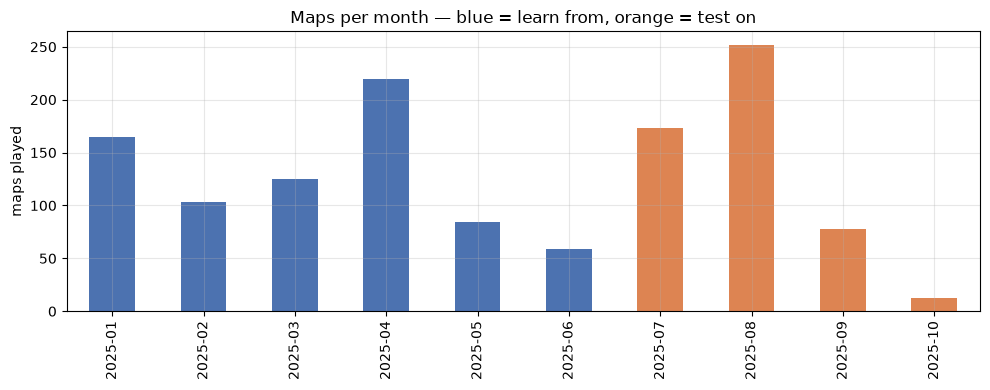

In [9]:
monthly = maps.groupby([maps["played_at"].dt.to_period("M").astype(str)]).size()

colours = ["#4c72b0" if pd.Timestamp(m + "-01") < SPLIT_DATE else "#dd8452" for m in monthly.index]
ax = monthly.plot.bar(color=colours)
ax.set_ylabel("maps played")
ax.set_xlabel("")
ax.set_title("Maps per month — blue = learn from, orange = test on")
plt.tight_layout()
plt.show()

The testing side is larger than the usual rule of thumb (it is about 40% rather than 20%),
because that is where the tournament gap falls. That is a fair trade: a clean break
between tournaments is worth more here than hitting a particular ratio, and it leaves
over 500 maps to test on, which is plenty to judge a model by.

## 7. What we have, and what comes next

The table is built and checked: **1,272 maps**, no missing values, in date order, with the
winner recorded and the season split into a learning half and a testing half.

What we learned along the way:

- Team A wins 51% of maps, so anything we build has to beat a coin flip to be worth having.
- Choosing the map is worth about 4 extra wins per 100 — real, but small.
- Which agents get played changes a lot across the year, which is why we test on later
  matches rather than a random selection.

**Next:** turn each row into something a model can actually read. At the moment a team's
agents are stored as five names grouped together, and there are 459 different combinations
with a third of them used only once — far too varied to treat each combination as its own
thing. The plan is to describe a line-up by which agents are in it, rather than by the
combination as a whole, so that line-ups sharing most of their agents look similar to the
model instead of completely unrelated.